# 02 · EDA: calidad de los datos y análisis univariado

**Evento evaluativo 2 – Análisis de Datos (ITM, 2026-2)**
**Fase 2 del proyecto (primera parte).** Responsable del módulo: Samuel.

Base seleccionada en el notebook 01: **Hotel Booking Demand** (Antonio, de Almeida y Nunes, 2019).

Este módulo responde, en orden, las preguntas que hay que hacerle a una base **antes** de buscar relaciones:

1. ¿Qué falta y por qué falta? → valores faltantes
2. ¿Qué registros son imposibles o están repetidos? → inconsistencias y duplicados
3. ¿Qué valores son extremos y cuáles de ellos son errores? → atípicos
4. ¿Qué forma tienen las variables? → distribuciones y análisis univariado

Cada sección termina con una **decisión** de limpieza. Al final esas decisiones quedan en la función `limpiar()`, que reutilizan los notebooks 03 y 04.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
AZUL, NARANJA, GRIS = "#0072B2", "#D55E00", "#6E6E6E"

URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(URL)
print("Dimensiones:", df.shape)
df.sample(5, random_state=7).T

Dimensiones: (119390, 32)


,71902,51736,101138,28656,52793
hotel,City Hotel,City Hotel,City Hotel,Resort Hotel,City Hotel
is_canceled,1,1,0,0,1
lead_time,53,158,48,383,69
arrival_date_year,2017,2016,2016,2016,2016
arrival_date_month,July,May,November,October,June
arrival_date_week_number,28,22,46,41,25
arrival_date_day_of_month,15,24,6,6,12
stays_in_weekend_nights,1,0,1,0,2
stays_in_week_nights,1,2,0,3,4
adults,2,1,2,2,1


### Qué significa cada grupo de variables

| Grupo | Variables | Qué miden |
|---|---|---|
| Objetivo | `is_canceled` | 1 si la reserva se canceló |
| Tiempo | `lead_time`, `arrival_date_*`, `days_in_waiting_list` | Anticipación de la reserva y fecha de llegada |
| Estadía | `stays_in_weekend_nights`, `stays_in_week_nights`, `adults`, `children`, `babies`, `meal` | Duración y composición del grupo |
| Canal | `market_segment`, `distribution_channel`, `agent`, `company`, `country` | Por dónde y desde dónde se reservó |
| Historial | `is_repeated_guest`, `previous_cancellations`, `previous_bookings_not_canceled` | Comportamiento previo del cliente |
| Condiciones | `deposit_type`, `customer_type`, `reserved_room_type`, `assigned_room_type`, `booking_changes`, `adr` | Depósito, habitación, cambios y tarifa diaria promedio (ADR, en euros) |
| Servicios | `required_car_parking_spaces`, `total_of_special_requests` | Parqueadero y solicitudes especiales |
| Estado final | `reservation_status`, `reservation_status_date` | Cómo y cuándo terminó la reserva |

## 1. Valores faltantes

Primero cuantificamos. Después preguntamos algo más importante que *cuánto falta*: **por qué falta**. El tratamiento depende de esa respuesta.

          faltantes  porcentaje
company      112593       94.31
agent         16340       13.69
country         488        0.41
children          4        0.00


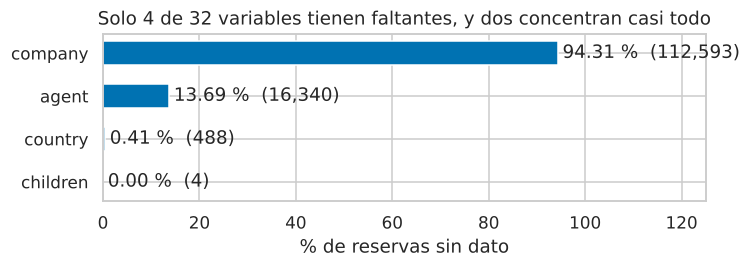

In [2]:
faltantes = pd.DataFrame({"faltantes": df.isna().sum(), "porcentaje": df.isna().mean().mul(100).round(2)})
faltantes = faltantes[faltantes["faltantes"] > 0].sort_values("porcentaje", ascending=False)
print(faltantes.to_string())

fig, ax = plt.subplots(figsize=(7, 2.6))
barras = ax.barh(faltantes.index[::-1], faltantes["porcentaje"][::-1], color=AZUL, height=0.55)
for b, n in zip(barras, faltantes["faltantes"][::-1]):
    ax.text(b.get_width() + 1, b.get_y() + b.get_height() / 2, f"{b.get_width():.2f} %  ({n:,})", va="center")
ax.set(xlim=(0, 125), xlabel="% de reservas sin dato", title="Solo 4 de 32 variables tienen faltantes, y dos concentran casi todo")
plt.tight_layout()
plt.show()

Usamos una gráfica de barras y no el mapa de calor de nulos del video de referencia, porque con 119 mil filas el mapa de calor no se alcanza a leer y con las barras se ve el porcentaje exacto.

### ¿Los datos faltan al azar?

`agent` y `company` son los códigos de la agencia y de la empresa que hizo la reserva. Si faltaran al azar, el porcentaje de faltantes debería ser parecido en todos los segmentos. Lo revisamos.

In [3]:
aux = df.assign(sin_agente=df["agent"].isna(), sin_empresa=df["company"].isna())

por_canal = aux.groupby("market_segment")[["sin_agente", "sin_empresa"]].mean().mul(100).round(1)
por_canal["reservas"] = aux["market_segment"].value_counts()
print("Porcentaje de reservas sin agente / sin empresa, por segmento:")
print(por_canal.sort_values("sin_agente", ascending=False).to_string())

print("\nTasa de cancelación según si el dato existe:")
for col, nombre in [("sin_agente", "agente"), ("sin_empresa", "empresa")]:
    t = aux.groupby(col)["is_canceled"].mean().mul(100).round(1)
    print(f"  Con {nombre}: {t[False]} %   |   Sin {nombre}: {t[True]} %")

Porcentaje de reservas sin agente / sin empresa, por segmento:
                sin_agente  sin_empresa  reservas
market_segment                                   
Undefined            100.0        100.0         2
Aviation              89.5         10.5       237
Corporate             86.8         15.6      5295
Complementary         86.1         57.9       743
Direct                47.7         98.3     12606
Groups                20.9         93.0     19811
Offline TA/TO          1.6         99.6     24219
Online TA              0.6         99.8     56477

Tasa de cancelación según si el dato existe:
  Con agente: 39.0 %   |   Sin agente: 24.7 %
  Con empresa: 17.5 %   |   Sin empresa: 38.2 %


**Interpretación.** Vemos que el faltante **no es al azar**. `agent` casi nunca falta en las reservas por agencia (Online TA y Offline TA/TO) y falta mucho en las directas y corporativas. Buscamos en el artículo original y dice que en estas dos columnas `NULL` significa *"no aplica"*: la reserva no se hizo por agencia o no la hizo una empresa. Entonces no es un dato perdido, es información.

Además se relaciona con la cancelación: las reservas sin agente cancelan 24,7 % y las que tienen agente 39 %. Si hubiéramos rellenado con la moda le habríamos inventado una agencia a 16 mil reservas, y si hubiéramos borrado las filas con faltantes habríamos perdido el 94 % de la base por la columna `company`.

### Qué hicimos con cada variable

| Variable | Faltantes | Mecanismo | Tratamiento |
|---|---|---|---|
| `company` | 94,31 % | No aplica (la reserva no es de empresa) | **Indicador** `tiene_empresa` (0/1) y se elimina la columna |
| `agent` | 13,69 % | No aplica (reserva sin agencia) | **Indicador** `tiene_agente` (0/1); el ID se conserva como categoría, con "0" = sin agente |
| `country` | 0,41 % | Dato no registrado | Nueva categoría **"Desconocido"** (no inventamos un país) |
| `children` | 4 filas | Dato no registrado | **Imputación** con la mediana y la moda, que coinciden: 0 |

Así usamos las estrategias que menciona el enunciado (eliminar, imputar, crear un indicador, crear una categoría), cada una según el caso.

## 2. Inconsistencias y duplicados

Un dato puede estar presente y aun así ser imposible. Revisamos reglas de negocio.

In [4]:
huespedes = df["adults"] + df["children"].fillna(0) + df["babies"]
noches = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

reglas = pd.Series({
    "Reservas con 0 huéspedes": (huespedes == 0).sum(),
    "Reservas con 0 noches": (noches == 0).sum(),
    "Tarifa (adr) negativa": (df["adr"] < 0).sum(),
    "Tarifa (adr) igual a 0": (df["adr"] == 0).sum(),
    "Tarifa (adr) mayor a 1.000 €": (df["adr"] > 1000).sum(),
    "Reservas sin adultos pero con niños": ((df["adults"] == 0) & (huespedes > 0)).sum(),
    "meal = 'Undefined'": (df["meal"] == "Undefined").sum(),
    "market_segment = 'Undefined'": (df["market_segment"] == "Undefined").sum(),
}, name="registros")
print(reglas.to_string())

print("\nSegmento de las reservas con tarifa 0:")
print(df.loc[df["adr"] == 0, "market_segment"].value_counts().head(4).to_string())

Reservas con 0 huéspedes                180
Reservas con 0 noches                   715
Tarifa (adr) negativa                     1
Tarifa (adr) igual a 0                 1959
Tarifa (adr) mayor a 1.000 €              1
Reservas sin adultos pero con niños     223
meal = 'Undefined'                     1169
market_segment = 'Undefined'              2

Segmento de las reservas con tarifa 0:
market_segment
Complementary    680
Online TA        367
Offline TA/TO    332
Groups           252


**Decisiones.**

- **0 huéspedes** y **tarifa negativa**: no pueden existir, las eliminamos.
- **Tarifa mayor a 1.000 €**: es una sola reserva de 5.400 € por noche (las demás no pasan de 510 €). Creemos que es un error de digitación y la eliminamos. La volvemos a mirar en la parte de atípicos.
- **Tarifa 0**: pensamos que era un error, pero muchas son cortesías (segmento *Complementary*), así que las dejamos.
- **`meal = 'Undefined'`**: según el artículo es lo mismo que `SC` (sin plan de comidas), entonces las unimos.
- **`agent` y `company`** están guardadas como números, pero son códigos. Sacarles un promedio no tiene sentido, por eso no las incluimos en las estadísticas numéricas.

### Filas repetidas

In [5]:
dup = df.duplicated()
print(f"Filas que repiten exactamente a otra anterior: {dup.sum():,} ({100 * dup.mean():.1f} %)")

aux = df.assign(repetida=dup)
print("\n% de filas repetidas por segmento:")
print(aux.groupby("market_segment")["repetida"].mean().mul(100).round(1).sort_values(ascending=False).to_string())
print("\n% de filas repetidas por tipo de depósito:")
print(aux.groupby("deposit_type")["repetida"].mean().mul(100).round(1).to_string())

Filas que repiten exactamente a otra anterior: 31,994 (26.8 %)

% de filas repetidas por segmento:
market_segment
Groups           75.1
Offline TA/TO    42.7
Corporate        20.5
Online TA         8.6
Direct            6.4
Complementary     5.5
Aviation          4.2
Undefined         0.0

% de filas repetidas por tipo de depósito:
deposit_type
No Deposit    17.6
Non Refund    92.9
Refundable    34.0


                       Con repetidas  Sin repetidas
Reservas                    119390.0        87396.0
% canceladas                    37.0           27.5
Reservas 'Non Refund'        14587.0         1038.0


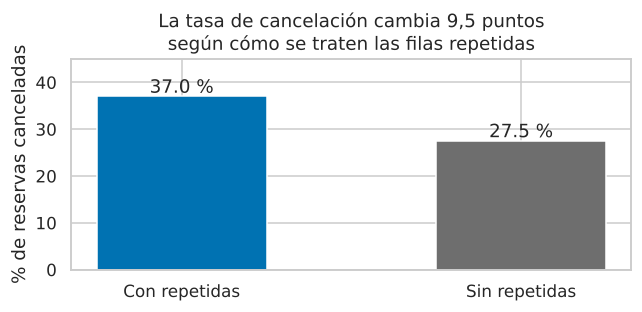

In [6]:
sin_dup = df.drop_duplicates()

comparacion = pd.DataFrame({
    "Con repetidas": [len(df), df["is_canceled"].mean() * 100,
                      (df["deposit_type"] == "Non Refund").sum()],
    "Sin repetidas": [len(sin_dup), sin_dup["is_canceled"].mean() * 100,
                      (sin_dup["deposit_type"] == "Non Refund").sum()],
}, index=["Reservas", "% canceladas", "Reservas 'Non Refund'"]).round(1)
print(comparacion.to_string())

fig, ax = plt.subplots(figsize=(6, 3))
valores = comparacion.loc["% canceladas"]
ax.bar(valores.index, valores.values, color=[AZUL, GRIS], width=0.5)
for i, v in enumerate(valores.values):
    ax.text(i, v + 0.8, f"{v:.1f} %", ha="center")
ax.set(ylim=(0, 45), ylabel="% de reservas canceladas",
       title="La tasa de cancelación cambia 9,5 puntos\nsegún cómo se traten las filas repetidas")
plt.tight_layout()
plt.show()

**Interpretación.** Esto fue lo que más nos sorprendió: una de cada cuatro filas es copia exacta de otra. Lo primero que pensamos fue usar `drop_duplicates()`, pero encontramos dos razones para no hacerlo sin pensar:

1. **La base no tiene un identificador de reserva** (los autores lo quitaron al anonimizar). Sin eso no podemos saber si una fila repetida es un error o son dos reservas distintas que quedaron iguales.
2. **Las repetidas no están repartidas por igual:** el 75 % de las reservas de *Groups* y el 93 % de las *Non Refund* son repetidas. Eso tiene sentido si una agencia reserva 20 habitaciones iguales el mismo día: quedan 20 filas idénticas, pero son reservas reales.

**Decisión:** las dejamos, porque cada fila sería una habitación reservada. Pero dejamos anotado que la tasa de cancelación cambia de **37,0 % a 27,5 %** si se quitan, y que *Non Refund* pasa de 14.587 filas a 1.038 filas distintas. Por eso en el notebook 03 repetimos las pruebas de hipótesis sin duplicados, para ver si las conclusiones cambian.

## 3. Valores atípicos

Usamos dos métodos estadísticos, implementados con funciones propias, y los contrastamos con gráficas:

- **Rango intercuartílico (IQR):** es atípico lo que queda por fuera de $[Q_1 - 1{,}5\cdot IQR,\; Q_3 + 1{,}5\cdot IQR]$. No supone ninguna distribución.
- **Puntaje z:** es atípico lo que está a más de 3 desviaciones estándar de la media, $|z| = |x - \bar{x}| / s > 3$. Supone una distribución aproximadamente normal.

In [7]:
def atipicos_iqr(serie, k=1.5):
    """Máscara booleana de los valores fuera de [Q1 - k·IQR, Q3 + k·IQR]."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return (serie < q1 - k * iqr) | (serie > q3 + k * iqr)


def atipicos_z(serie, umbral=3):
    """Máscara booleana de los valores con |z| mayor al umbral."""
    z = (serie - serie.mean()) / serie.std()
    return z.abs() > umbral


numericas = ["lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children", "babies",
             "previous_cancellations", "previous_bookings_not_canceled", "booking_changes",
             "days_in_waiting_list", "required_car_parking_spaces", "total_of_special_requests"]

resumen = pd.DataFrame({
    "IQR (n)": [atipicos_iqr(df[c].dropna()).sum() for c in numericas],
    "IQR (%)": [100 * atipicos_iqr(df[c].dropna()).mean() for c in numericas],
    "z > 3 (n)": [atipicos_z(df[c].dropna()).sum() for c in numericas],
    "z > 3 (%)": [100 * atipicos_z(df[c].dropna()).mean() for c in numericas],
    "Q3": [df[c].quantile(0.75) for c in numericas],
    "máximo": [df[c].max() for c in numericas],
}, index=numericas).round(2)
resumen

,IQR (n),IQR (%),z > 3 (n),z > 3 (%),Q3,máximo
lead_time,3005,2.52,1454,1.22,160.0,737.0
adr,3793,3.18,1138,0.95,126.0,5400.0
stays_in_weekend_nights,265,0.22,2199,1.84,2.0,19.0
stays_in_week_nights,3354,2.81,1669,1.40,3.0,50.0
adults,29710,24.88,481,0.40,2.0,55.0
children,8590,7.20,3729,3.12,0.0,10.0
babies,917,0.77,917,0.77,0.0,10.0
previous_cancellations,6484,5.43,317,0.27,0.0,26.0
previous_bookings_not_canceled,3620,3.03,936,0.78,0.0,72.0
booking_changes,18076,15.14,1570,1.32,0.0,21.0


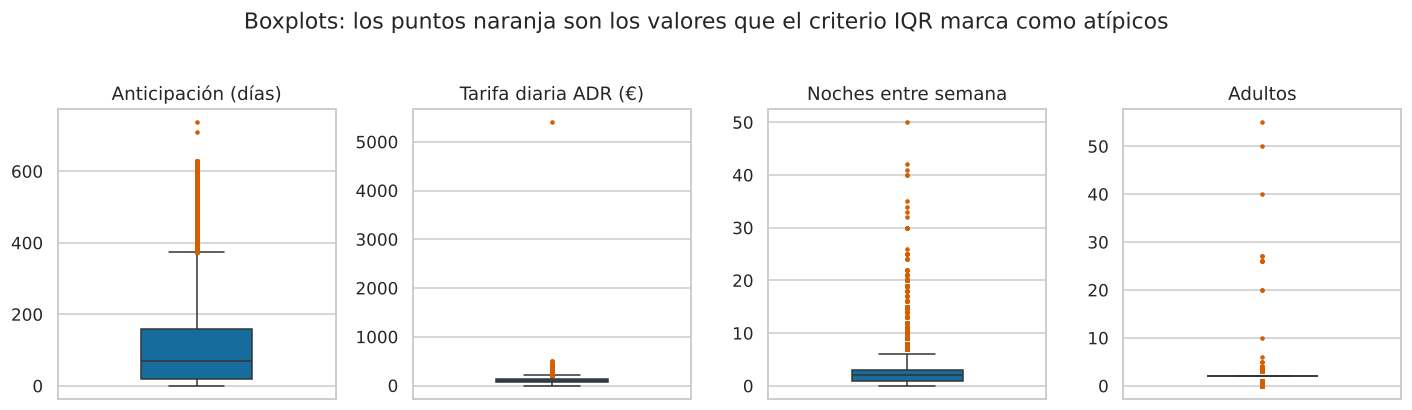

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(13, 3.6))
for eje, col, titulo in zip(ax, ["lead_time", "adr", "stays_in_week_nights", "adults"],
                            ["Anticipación (días)", "Tarifa diaria ADR (€)", "Noches entre semana", "Adultos"]):
    sns.boxplot(y=df[col], ax=eje, color=AZUL, width=0.4, fliersize=2,
                flierprops={"markerfacecolor": NARANJA, "markeredgecolor": NARANJA})
    eje.set(title=titulo, ylabel="")
fig.suptitle("Boxplots: los puntos naranja son los valores que el criterio IQR marca como atípicos", y=1.03)
plt.tight_layout()
plt.show()

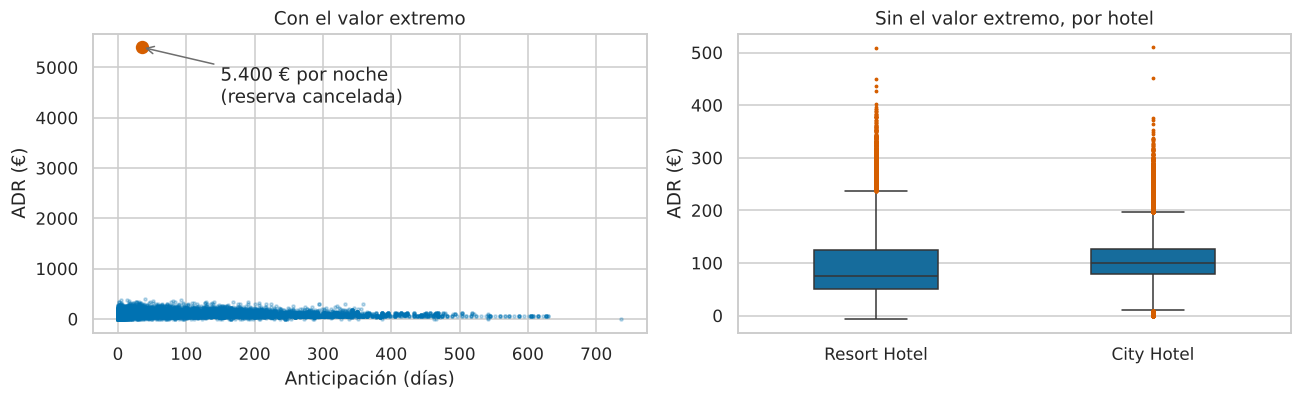

Las 5 tarifas más altas:
               hotel     adr  adults  is_canceled market_segment
48515     City Hotel  5400.0       2            1  Offline TA/TO
111403    City Hotel   510.0       1            0  Offline TA/TO
15083   Resort Hotel   508.0       2            0      Corporate
103912    City Hotel   451.5       2            0         Direct
13142   Resort Hotel   450.0       2            1      Online TA


In [9]:
# El boxplot de ADR queda aplastado por un solo punto. Lo miramos en un diagrama de dispersión.
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))

muestra = df.sample(15000, random_state=1)
ax[0].scatter(muestra["lead_time"], muestra["adr"], s=4, alpha=0.25, color=AZUL)
extremo = df.loc[df["adr"].idxmax()]
ax[0].scatter(extremo["lead_time"], extremo["adr"], s=60, color=NARANJA, zorder=3)
ax[0].annotate("5.400 € por noche\n(reserva cancelada)", (extremo["lead_time"], extremo["adr"]),
               xytext=(150, 4300), arrowprops={"arrowstyle": "->", "color": GRIS})
ax[0].set(xlabel="Anticipación (días)", ylabel="ADR (€)", title="Con el valor extremo")

sin_extremo = df[df["adr"] < 1000]
sns.boxplot(data=sin_extremo, x="hotel", y="adr", ax=ax[1], color=AZUL, width=0.45, fliersize=1.5,
            flierprops={"markerfacecolor": NARANJA, "markeredgecolor": NARANJA})
ax[1].set(xlabel="", ylabel="ADR (€)", title="Sin el valor extremo, por hotel")
plt.tight_layout()
plt.show()

print("Las 5 tarifas más altas:")
print(df.nlargest(5, "adr")[["hotel", "adr", "adults", "is_canceled", "market_segment"]].to_string())

**Interpretación.** Los dos métodos dan resultados diferentes, y al revisar entendimos por qué:

- En variables que casi siempre valen cero (`previous_cancellations`, `booking_changes`, `children`, `required_car_parking_spaces`) el IQR da 0, entonces el método marca como atípico **todo lo que no sea cero**. Con `adults` pasa algo parecido: casi todas las reservas son de 2 adultos, y por eso marca como atípica una de cada cuatro. Ahí el problema es del método, no de los datos.
- El puntaje z marca menos casos, pero usa la media y la desviación estándar, y en variables tan sesgadas esas dos medidas ya están afectadas por los mismos valores extremos.

Por eso no borramos automáticamente lo que marcan los métodos, sino que decidimos variable por variable:

| Variable | Qué encontramos | Decisión |
|---|---|---|
| `adr` | Un valor de 5.400 €, más de 10 veces el siguiente; uno negativo | **Eliminar** esos 2 registros: son errores |
| `adr` (resto) | Tarifas de 200–500 € en temporada alta | **Conservar**: son precios reales |
| `lead_time` | Reservas con más de un año de anticipación | **Conservar** y tratar el sesgo con logaritmo (notebook 04) |
| `adults` | Reservas con 20–55 adultos | **Conservar**: son grupos, todas del resort y canceladas; se documenta |
| `babies` | Dos reservas con 9 y 10 bebés | **Conservar**: no alteran ningún análisis; se documenta como sospechoso |
| Variables de conteo en cero | El IQR marca todo lo distinto de cero | **Conservar**: no son atípicos, es la naturaleza de la variable |

Si hubiéramos eliminado todo lo que marca el IQR en `lead_time`, habríamos quitado las reservas con más anticipación, que como se ve en el notebook 03 son las que más cancelan.

## 4. Limpieza aplicada

Reunimos las decisiones de las secciones 1 a 3 en una sola función. Los notebooks 03 y 04 usan exactamente la misma.

In [10]:
def limpiar(datos):
    """Aplica las decisiones de calidad justificadas en este notebook."""
    d = datos.copy()

    # Faltantes
    d["children"] = d["children"].fillna(0).astype(int)          # imputación (mediana = moda = 0)
    d["country"] = d["country"].fillna("Desconocido")            # categoría nueva
    d["tiene_agente"] = d["agent"].notna().astype(int)           # indicador: el faltante es información
    d["tiene_empresa"] = d["company"].notna().astype(int)
    d["agent"] = d["agent"].fillna(0).astype(int).astype(str)    # ID como categoría ("0" = sin agente)
    d = d.drop(columns="company")                                # 94 % sin dato

    # Inconsistencias
    d["meal"] = d["meal"].replace("Undefined", "SC")
    d["huespedes"] = d["adults"] + d["children"] + d["babies"]
    d["noches"] = d["stays_in_weekend_nights"] + d["stays_in_week_nights"]
    d = d[(d["huespedes"] > 0) & (d["adr"] >= 0) & (d["adr"] < 1000)]

    return d.reset_index(drop=True)


limpio = limpiar(df)
print(f"Antes : {df.shape[0]:,} filas, {df.shape[1]} columnas")
print(f"Después: {limpio.shape[0]:,} filas, {limpio.shape[1]} columnas")
print(f"Filas eliminadas: {len(df) - len(limpio)} ({100 * (len(df) - len(limpio)) / len(df):.2f} %)")
print("Faltantes restantes:", int(limpio.isna().sum().sum()))

Antes : 119,390 filas, 32 columnas
Después: 119,208 filas, 35 columnas
Filas eliminadas: 182 (0.15 %)
Faltantes restantes: 0


## 5. Distribuciones

Miramos la forma de las dos variables numéricas continuas más importantes, `lead_time` y `adr`, con histograma y curva de densidad. La pregunta es si se parecen a una normal o si van a necesitar una transformación antes de escalarlas.

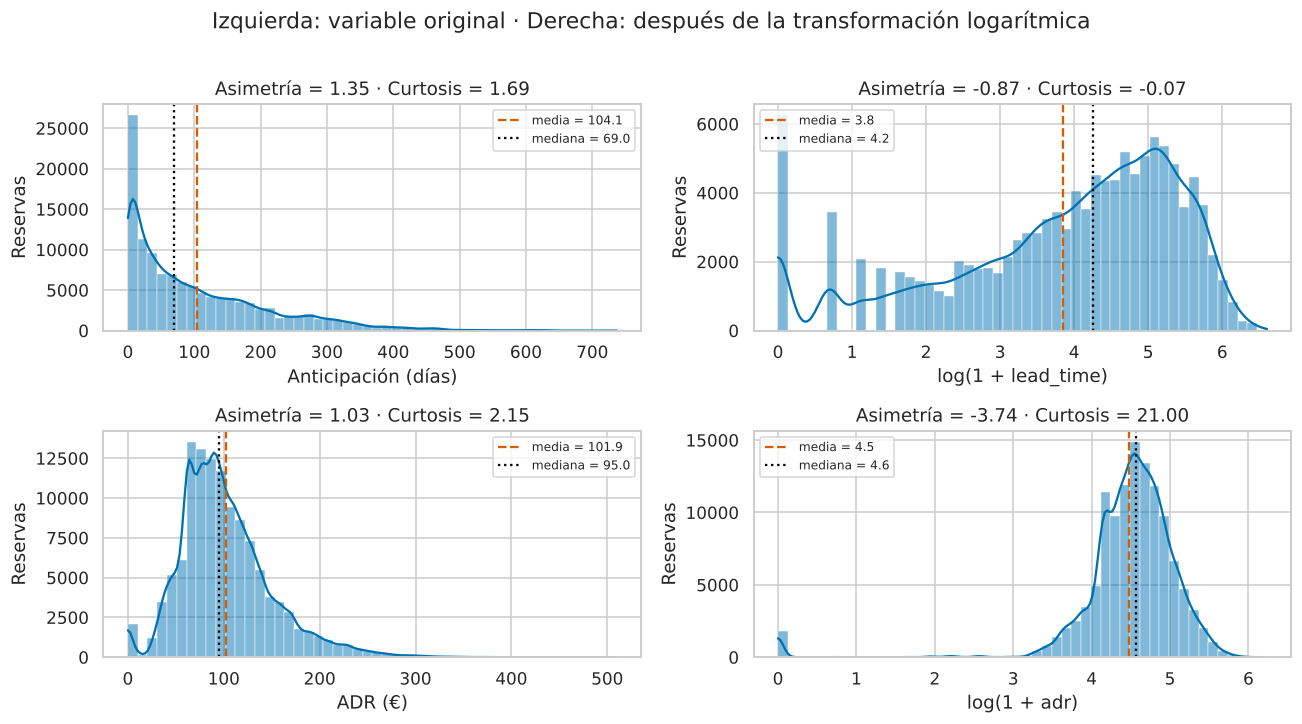

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6.5))
for fila, (col, nombre) in enumerate([("lead_time", "Anticipación (días)"), ("adr", "ADR (€)")]):
    original = limpio[col]
    transformada = np.log1p(original)
    for eje, serie, etiqueta in [(ax[fila, 0], original, nombre), (ax[fila, 1], transformada, f"log(1 + {col})")]:
        sns.histplot(serie, bins=50, kde=True, color=AZUL, ax=eje, edgecolor="white", linewidth=0.3)
        eje.axvline(serie.mean(), color=NARANJA, linestyle="--", label=f"media = {serie.mean():.1f}")
        eje.axvline(serie.median(), color="black", linestyle=":", label=f"mediana = {serie.median():.1f}")
        eje.set(xlabel=etiqueta, ylabel="Reservas", title=f"Asimetría = {serie.skew():.2f} · Curtosis = {serie.kurt():.2f}")
        eje.legend(fontsize=8)
fig.suptitle("Izquierda: variable original · Derecha: después de la transformación logarítmica", y=1.01)
plt.tight_layout()
plt.show()

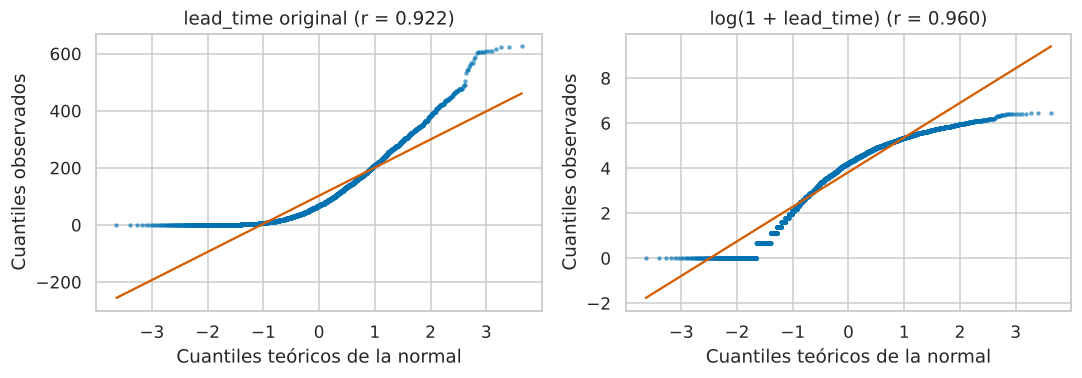

In [12]:
# Gráfico cuantil-cuantil: si los puntos siguen la diagonal, la variable se parece a una normal.
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
muestra = limpio["lead_time"].sample(5000, random_state=1)
for eje, serie, titulo in [(ax[0], muestra, "lead_time original"), (ax[1], np.log1p(muestra), "log(1 + lead_time)")]:
    (cuantiles_t, cuantiles_m), (pendiente, corte, r) = stats.probplot(serie, dist="norm")
    eje.scatter(cuantiles_t, cuantiles_m, s=4, color=AZUL, alpha=0.5)
    eje.plot(cuantiles_t, pendiente * cuantiles_t + corte, color=NARANJA)
    eje.set(title=f"{titulo} (r = {r:.3f})", xlabel="Cuantiles teóricos de la normal", ylabel="Cuantiles observados")
plt.tight_layout()
plt.show()

**Interpretación.**

- **`lead_time`** tiene asimetría positiva (1,35): la mayoría reserva con poca anticipación y hay una cola larga hacia la derecha que llega a dos años. La media (104 días) queda bastante por encima de la mediana (69), por eso creemos que la mediana describe mejor esta variable.
- Con `log(1 + x)` la cola derecha se corrige, pero la asimetría queda negativa (−0,87), porque hay muchas reservas hechas el mismo día (lead_time = 0) que se acumulan a la izquierda. Mejora, pero no queda normal, y en el gráfico cuantil-cuantil se ve que los puntos todavía se separan de la línea en los extremos.
- **`adr`** tiene una asimetría moderada (1,03) después de quitar el valor de 5.400 €. Aquí el logaritmo la empeora (pasa a −3,74) por las tarifas en cero. Entonces decidimos transformar `lead_time` y dejar `adr` como está.

No hicimos una prueba de normalidad porque con casi 120 mil datos esas pruebas rechazan la normalidad por diferencias muy pequeñas. Nos pareció más útil mirar la asimetría, la curtosis y la gráfica.

## 6. Análisis univariado

### Variables numéricas

Para cada variable calculamos tendencia central (media, mediana, moda), dispersión (desviación estándar, IQR, coeficiente de variación) y forma (asimetría, curtosis).

In [13]:
num_cols = ["lead_time", "adr", "noches", "huespedes", "stays_in_weekend_nights", "stays_in_week_nights",
            "previous_cancellations", "previous_bookings_not_canceled", "booking_changes",
            "days_in_waiting_list", "required_car_parking_spaces", "total_of_special_requests"]

univariado = pd.DataFrame({
    "media": limpio[num_cols].mean(),
    "mediana": limpio[num_cols].median(),
    "moda": limpio[num_cols].mode().iloc[0],
    "desv. estándar": limpio[num_cols].std(),
    "IQR": limpio[num_cols].quantile(0.75) - limpio[num_cols].quantile(0.25),
    "coef. variación": limpio[num_cols].std() / limpio[num_cols].mean(),
    "asimetría": limpio[num_cols].skew(),
    "curtosis": limpio[num_cols].kurt(),
    "% en cero": (limpio[num_cols] == 0).mean() * 100,
}).round(2)
univariado

,media,mediana,moda,desv. estándar,IQR,coef. variación,asimetría,curtosis,% en cero
lead_time,104.11,69.00,0.0,106.88,143.0,1.03,1.35,1.69,5.25
adr,101.93,94.95,62.0,48.04,56.5,0.47,1.03,2.15,1.52
noches,3.43,3.00,2.0,2.54,2.0,0.74,3.19,26.49,0.54
huespedes,1.97,2.00,2.0,0.72,0.0,0.36,10.34,566.24,0.00
stays_in_weekend_nights,0.93,1.00,0.0,1.00,2.0,1.07,1.32,6.37,43.53
stays_in_week_nights,2.50,2.00,2.0,1.90,2.0,0.76,2.75,22.25,6.35
previous_cancellations,0.09,0.00,0.0,0.84,0.0,9.69,24.44,673.21,94.56
previous_bookings_not_canceled,0.14,0.00,0.0,1.50,0.0,10.93,23.54,766.96,96.97
booking_changes,0.22,0.00,0.0,0.64,0.0,2.92,5.50,63.45,84.92
days_in_waiting_list,2.32,0.00,0.0,17.60,0.0,7.58,11.95,186.89,96.90


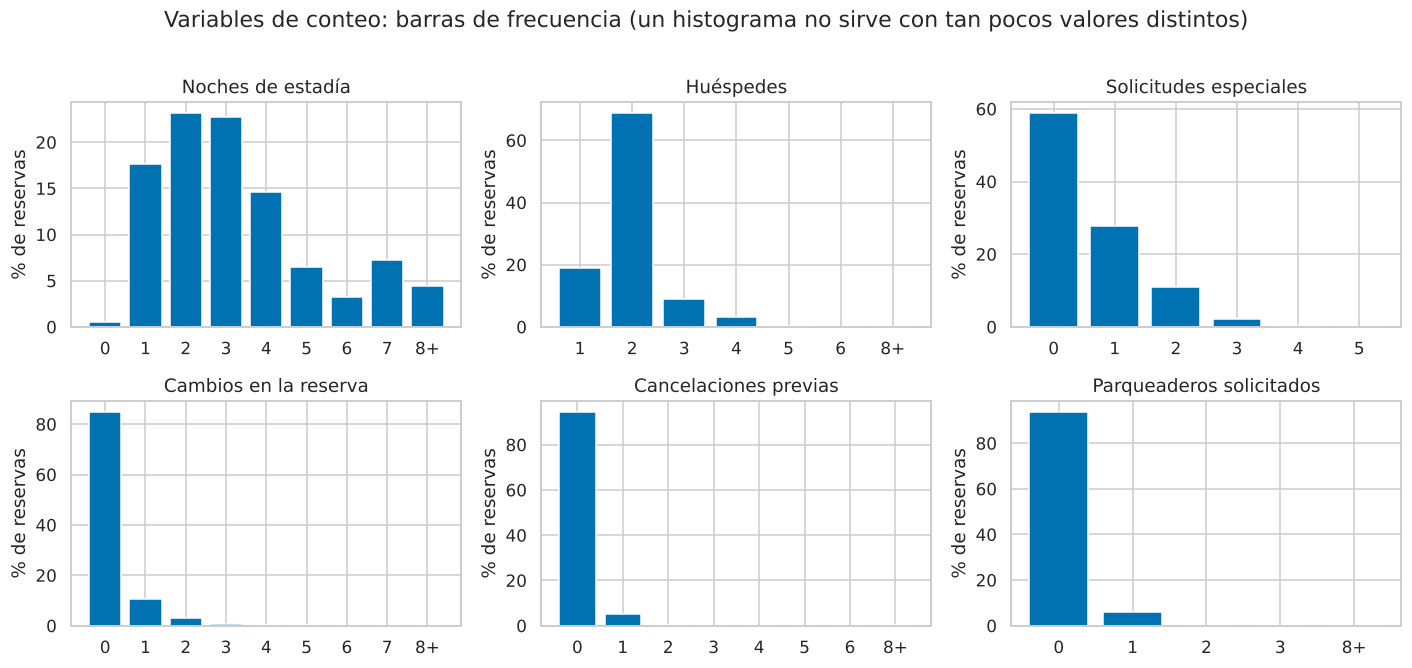

In [14]:
conteos = ["noches", "huespedes", "total_of_special_requests", "booking_changes",
           "previous_cancellations", "required_car_parking_spaces"]
titulos = ["Noches de estadía", "Huéspedes", "Solicitudes especiales", "Cambios en la reserva",
           "Cancelaciones previas", "Parqueaderos solicitados"]

fig, ax = plt.subplots(2, 3, figsize=(13, 6))
for eje, col, titulo in zip(ax.ravel(), conteos, titulos):
    frec = limpio[col].clip(upper=8).value_counts(normalize=True).sort_index().mul(100)
    etiquetas = [str(int(v)) if v < 8 else "8+" for v in frec.index]
    eje.bar(etiquetas, frec.values, color=AZUL)
    eje.set(title=titulo, ylabel="% de reservas")
fig.suptitle("Variables de conteo: barras de frecuencia (un histograma no sirve con tan pocos valores distintos)", y=1.01)
plt.tight_layout()
plt.show()

**Interpretación.**

- Las variables de historial y servicios casi no cambian: más del 90 % de las reservas tiene cero cancelaciones previas, cero parqueaderos y cero días en lista de espera. Por eso la curtosis sale tan alta. En estas variables la media no dice mucho; lo que importa es si el valor es cero o no.
- Lo más común es una estadía de **3 noches** (mediana) con **2 huéspedes**.
- El coeficiente de variación de `adr` (0,47) es menor que el de `lead_time` (1,03): las tarifas se parecen más entre sí que los días de anticipación.
- Para las variables de conteo usamos barras, porque toman muy pocos valores distintos y un histograma con curva de densidad dibujaría una curva que en realidad no existe.

### Variables categóricas

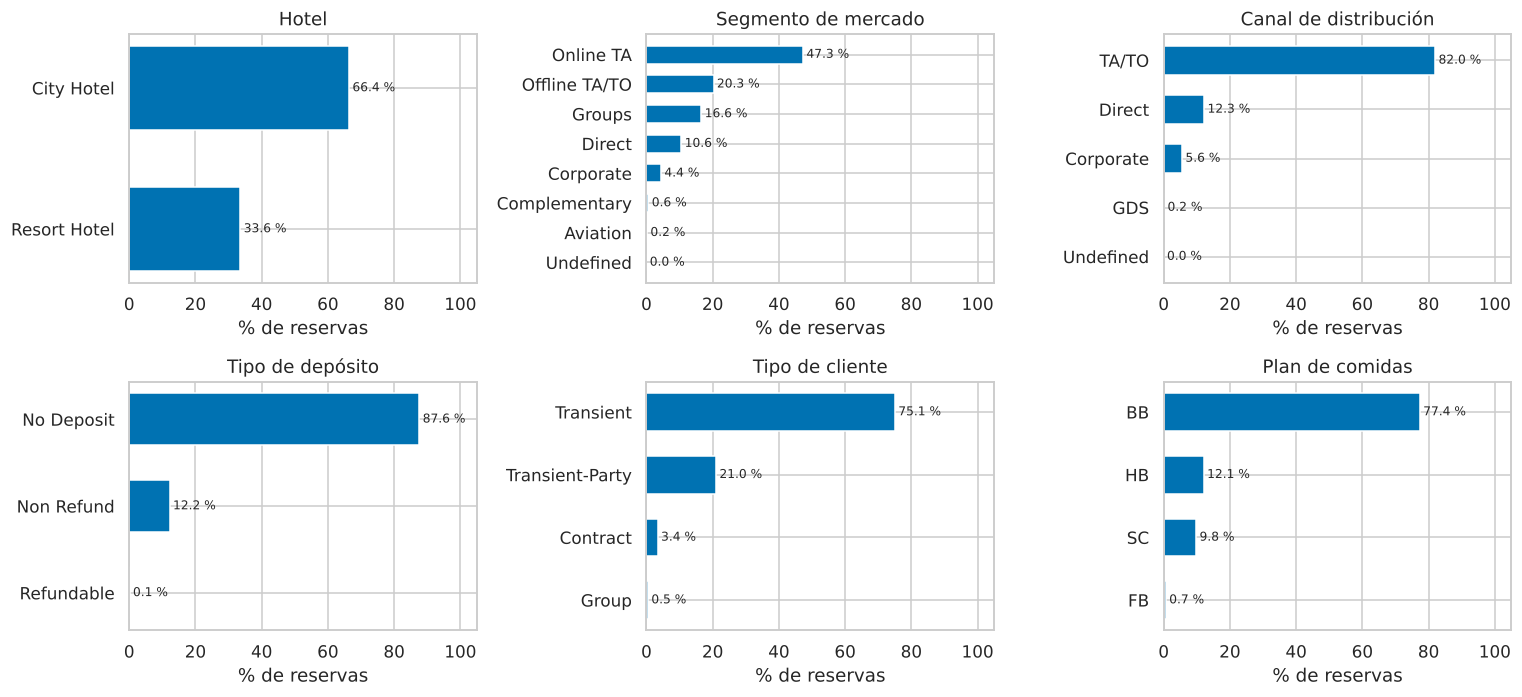

,categorías,moda,% de la moda
hotel,2,City Hotel,66.4
market_segment,8,Online TA,47.3
distribution_channel,5,TA/TO,82.0
deposit_type,3,No Deposit,87.6
customer_type,4,Transient,75.1
meal,4,BB,77.4
country,178,PRT,40.7
agent,334,9,26.8
reserved_room_type,9,A,72.0


In [15]:
cat_cols = ["hotel", "market_segment", "distribution_channel", "deposit_type", "customer_type", "meal"]
cat_tit = ["Hotel", "Segmento de mercado", "Canal de distribución", "Tipo de depósito", "Tipo de cliente", "Plan de comidas"]

fig, ax = plt.subplots(2, 3, figsize=(14, 6.5))
for eje, col, titulo in zip(ax.ravel(), cat_cols, cat_tit):
    frec = limpio[col].value_counts(normalize=True).mul(100).sort_values()
    barras = eje.barh(frec.index, frec.values, color=AZUL, height=0.6)
    for b in barras:
        eje.text(b.get_width() + 1, b.get_y() + b.get_height() / 2, f"{b.get_width():.1f} %", va="center", fontsize=8)
    eje.set(title=titulo, xlabel="% de reservas", xlim=(0, 105))
plt.tight_layout()
plt.show()

resumen_cat = pd.DataFrame({
    "categorías": limpio[cat_cols + ["country", "agent", "reserved_room_type"]].nunique(),
    "moda": limpio[cat_cols + ["country", "agent", "reserved_room_type"]].mode().iloc[0],
    "% de la moda": [limpio[c].value_counts(normalize=True).iloc[0] * 100 for c in cat_cols + ["country", "agent", "reserved_room_type"]],
}).round(1)
resumen_cat

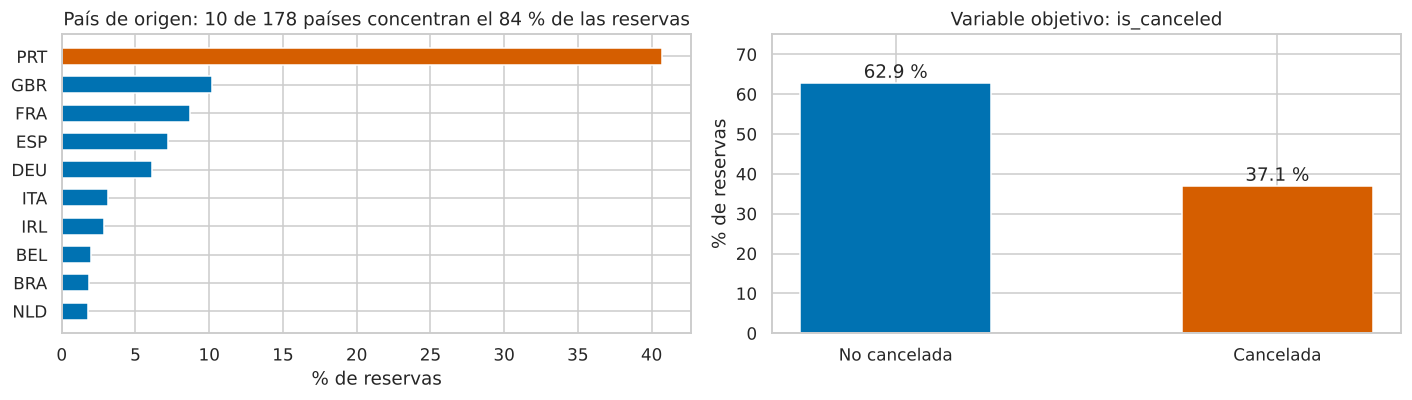

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))

paises = limpio["country"].value_counts(normalize=True).mul(100)
top = paises.head(10).sort_values()
ax[0].barh(top.index, top.values, color=[NARANJA if p == "PRT" else AZUL for p in top.index], height=0.6)
ax[0].set(title=f"País de origen: 10 de {limpio['country'].nunique()} países concentran el {paises.head(10).sum():.0f} % de las reservas",
          xlabel="% de reservas")

objetivo = limpio["is_canceled"].map({0: "No cancelada", 1: "Cancelada"}).value_counts(normalize=True).mul(100)
ax[1].bar(objetivo.index, objetivo.values, color=[AZUL, NARANJA], width=0.5)
for i, v in enumerate(objetivo.values):
    ax[1].text(i, v + 1.2, f"{v:.1f} %", ha="center")
ax[1].set(title="Variable objetivo: is_canceled", ylabel="% de reservas", ylim=(0, 75))
plt.tight_layout()
plt.show()

**Interpretación.**

- El hotel de ciudad tiene dos tercios de las reservas (66 %), así que cualquier promedio general se parece más a ese hotel. Por eso en el notebook 03 separamos por hotel.
- Hay categorías que concentran casi todo: *No Deposit* (88 %), *Transient* (75 %) y *BB* (77 %). Las categorías pequeñas, como *Refundable* con 162 reservas, hay que leerlas con cuidado porque con tan pocos datos el porcentaje cambia mucho.
- El número de categorías es muy distinto: `hotel` tiene 2 y `country` tiene 178. Esto lo tenemos en cuenta para la codificación en el notebook 04.
- Portugal tiene el 41 % de las reservas, que es el mercado local.
- La variable objetivo está algo desbalanceada: 37 % canceladas. Si un modelo dijera siempre "no cancela", acertaría el 63 %, así que ese sería el mínimo a superar.

## Cierre del módulo

**Problemas de calidad que encontramos**

1. Faltantes que no son al azar: en `agent` y `company` el vacío significa "no aplica".
2. 27 % de filas repetidas, sobre todo en reservas de grupo, y sin identificador para verificarlas.
3. Registros imposibles: 180 reservas sin huéspedes, una tarifa negativa y una de 5.400 €.
4. Códigos guardados como números (`agent`, `company`).
5. Variables de conteo llenas de ceros, donde el IQR no funciona bien.

**Lo que pasa al siguiente notebook:** la función `limpiar()`, que deja 119.208 reservas sin faltantes, y la advertencia de que la categoría *Non Refund* tiene muchas filas repetidas.

➡️ Continúa en `03_eda_multivariado_hipotesis.ipynb`.